In [1]:
import os
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs

In [2]:
filename = 'tas_mon_mod_ssp126_192_ave.nc' # SSPs:126, 245, 585

# 可以从 [https://www.kaggle.com/datasets/limited1984/cmip6-demo-data] 去下载数据。

In [3]:
# 打开这个NC文件

ncid = xr.open_dataset(filename)

# 因为源文件是K，转为摄氏度

ncid['tas'] = ncid['tas'] - 273.15

In [4]:
# 选取北半球的数据

ncid = ncid.sel(lat = slice(0,90))

In [5]:
# 选取一部分历史时期(1901-2014)的数据

ncid = ncid.sel(time = slice('1901','2014'))

In [6]:
# 计算年平均值

ncid = ncid.resample(time = '1YE').mean('time') 
ncid

<xarray.Dataset> Size: 6MB
Dimensions:  (time: 114, lat: 72, lon: 192)
Coordinates:
  * lon      (lon) float32 768B 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
  * lat      (lat) float32 288B 0.625 1.875 3.125 4.375 ... 86.88 88.12 89.38
    height   float64 8B 2.0
  * time     (time) datetime64[ns] 912B 1901-12-31 1902-12-31 ... 2014-12-31
Data variables:
    tas      (time, lat, lon) float32 6MB 26.63 26.7 26.76 ... -16.24 -16.23
Attributes: (12/21)
    CDI:                 Climate Data Interface version 1.9.9rc1 (https://mpi...
    history:             Tue Sep 19 15:16:48 2023: cdo -r -f nc4 -z zip ensme...
    Conventions:         CF-1.7 CMIP-6.2
    activity_id:         CMIP
    creation_date:       2024-04-16T10:32:50Z
    data_specs_version:  01.00.30
    ...                  ...
    CDO:                 Climate Data Operators version 1.9.9rc1 (https://mpi...
    institution:         KNMI
    title:               Multi-model mean (mean of all model means) of histor...
    license:             CMIP6 model data produced by KNMI is licensed under ...
    model_id:            multi-model (see title)
    contact:             climate-explorer@knmi.nl

/srv/conda/envs/notebook/lib/python3.10/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


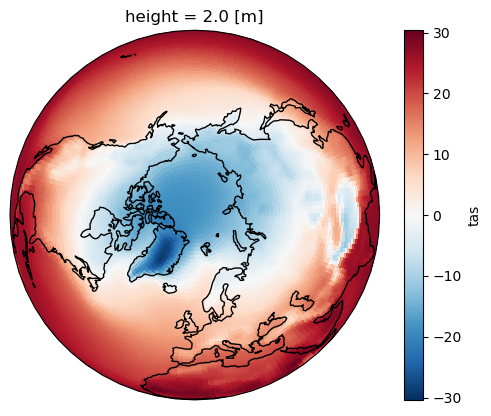

In [7]:
# 计算一下1971-2000期间的平均值，然后画个地图看看

fig, axis = plt.subplots(1, 1, subplot_kw=dict(projection=ccrs.Orthographic(0, 90)))

ncid.sel(time = slice('1971','2000')).mean('time')['tas'].plot(transform=ccrs.PlateCarree()),  # this is important!)

axis.coastlines()  # cartopy function

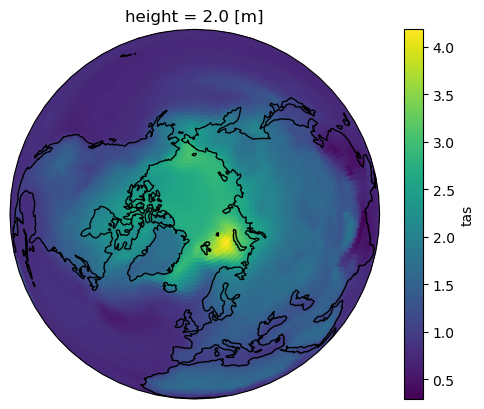

In [8]:
# 计算一下1871-1900期间的平均值
# 再计算一下2071-2100期间的平均值
# 用2071-2100减去1871-1900，然后画个地图看看两个时期之间的气温差异

t1901 = ncid.sel(time = slice('1901','1914')).mean('time')
t2001 = ncid.sel(time = slice('2001','2014')).mean('time')

fig, axis = plt.subplots(1, 1, subplot_kw=dict(projection=ccrs.Orthographic(0, 90)))

(t2001 - t1901)['tas'].plot(transform=ccrs.PlateCarree()),  # this is important!)

axis.coastlines()  # cartopy function

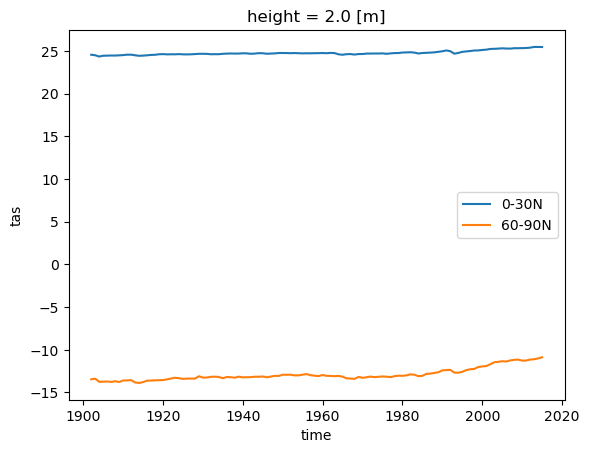

In [9]:
# 计算0-30N的平均气温
# 计算60-90N的平均气温
# 比较一下两个时间序列

ncid.sel(lat = slice(0,30)).mean('lat').mean('lon')['tas'].plot(label = '0-30N')
ncid.sel(lat = slice(60,90)).mean('lat').mean('lon')['tas'].plot(label = '60-90N')
plt.legend()

### <span style='color: red;'>Tips</span>: 你会发现，这两个序列差的太远了，不太好比较。
###     为了比较，往往会先计算距平值(Anomaly or Departure)

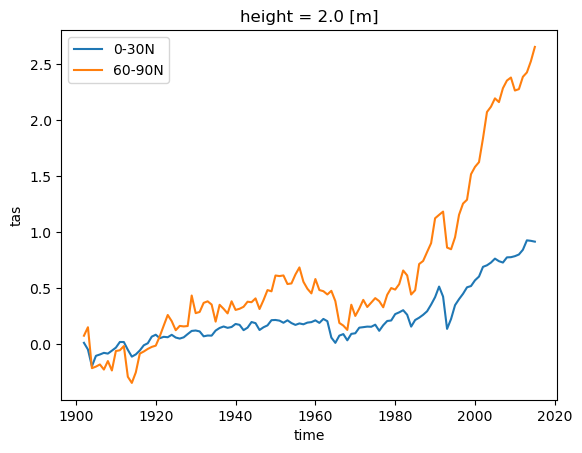

In [10]:
anom = ncid - ncid.sel(time = slice('1901','1930')).mean('time')

anom.sel(lat = slice(0,30)).mean('lat').mean('lon')['tas'].plot(label = '0-30N')
anom.sel(lat = slice(60,90)).mean('lat').mean('lon')['tas'].plot(label = '60-90N')

plt.legend()

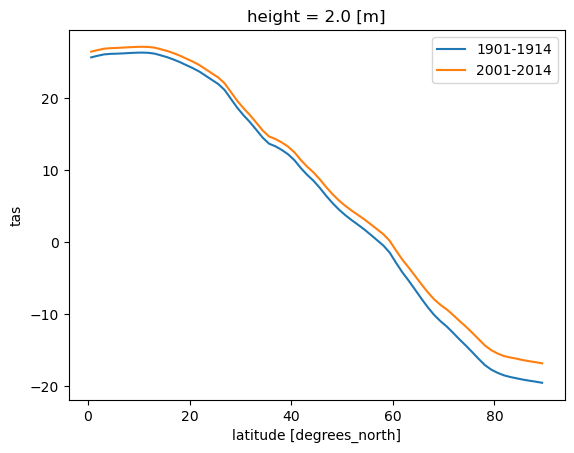

In [11]:
# 计算一下1901-1914年期间，不同纬度的平均气温
# 计算一下2001-2014年期间，不同纬度的平均气温

t1901.mean('lon')['tas'].plot(label = '1901-1914')
t2001.mean('lon')['tas'].plot(label = '2001-2014')

plt.legend()

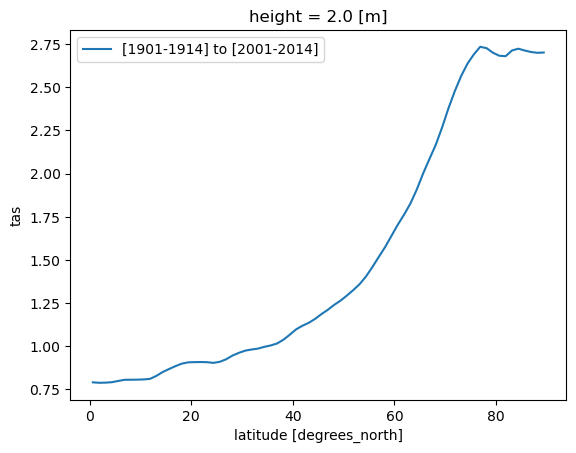

In [12]:
(t2001 - t1901).mean('lon')['tas'].plot(label = '[1901-1914] to [2001-2014]')

plt.legend()

## <span style='color: red;'>Q</span>: 同学们可以尝试看看用距平值（anom）计算结果如何？